# Gesture Recognition - Model Training

This notebook handles model definition, training, and evaluation.

**Output:** Trained model weights (.pth)

## 1. Environment Setup

In [33]:
# Check GPU
!nvidia-smi

NVIDIA-SMI has failed because it couldn't communicate with the NVIDIA driver. Make sure that the latest NVIDIA driver is installed and running.



In [34]:
import os
import json
import random
from collections import defaultdict

import cv2
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import matplotlib.pyplot as plt

from common.log import log_warn, log_err, log_info
from common.utils import to_scalar, resample, to_raw_sequence, compute_features
from common.gesture_tcn_model import GestureTCN

## 2. Mount Google Drive and Load Dataset Info

In [7]:
# Load dataset info
save_dir = "checkpoints"
info_path = os.path.join(save_dir, "dataset_info.json")

with open(info_path, "r", encoding="utf-8") as f:
    dataset_info = json.load(f)

# Set constants from dataset_info
SEQ_LEN = dataset_info["seq_len"]
FEATURE_DIM = dataset_info["feature_dim"]
RAW_DIM = dataset_info["raw_dim"]
NUM_CLASSES = dataset_info["num_classes"]
CLASS_NAMES = dataset_info["class_names"]
CACHE_VERSION = dataset_info["cache_version"]
PAIRS = [tuple(p) for p in dataset_info["pairs"]]
FINGER_CHAINS = dataset_info["finger_chains"]
N_FINGERS = dataset_info["n_fingers"]
N_PAIRS = len(PAIRS)
NUM_LANDMARKS = 21
NUM_COORDS = 3
WRIST_IDX = 0
MID_FINGER_IDX = 9

# Training hyperparameters
BATCH_SIZE = 32
EPOCHS = 300
LR = 2e-3
WEIGHT_DECAY = 1e-3
PATIENCE = 40

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Feature dim: {FEATURE_DIM}")
print(f"Classes: {CLASS_NAMES}")

Device: cpu
Feature dim: 144
Classes: ['grab', 'release', 'swipe_up', 'swipe_down', 'noise']


## 3. Load Preprocessed Data

In [8]:
# Load cache
cache_dir = os.path.join(save_dir, "cache")
tr_cache = os.path.join(cache_dir, f"train_{CACHE_VERSION}.npz")
te_cache = os.path.join(cache_dir, f"test_{CACHE_VERSION}.npz")


def load_cache(cache_path):
    log_info(f"Loading cache: {cache_path}")
    with np.load(cache_path, allow_pickle=True) as c:
        samples = np.asarray(c["samples"], dtype=np.float32)
        labels = np.asarray(c["labels"], dtype=np.int64)
    out_samples = [np.ascontiguousarray(s, dtype=np.float32) for s in samples]
    out_labels = labels.astype(np.int64).tolist()
    log_info(f"  {len(out_samples)} samples loaded")
    return out_samples, out_labels


train_samples, train_labels = load_cache(tr_cache)
test_samples, test_labels = load_cache(te_cache)

print(f"Train samples: {len(train_samples)}")
print(f"Test samples: {len(test_samples)}")

[21:55:42] INFO - Loading cache: checkpoints/cache/train_v3_fixed_swipe_reverse.npz
[21:55:42] INFO -   3018 samples loaded
[21:55:42] INFO - Loading cache: checkpoints/cache/test_v3_fixed_swipe_reverse.npz
[21:55:42] INFO -   29 samples loaded
Train samples: 3018
Test samples: 29


In [9]:
# Load normalization stats
norm_stats = torch.load(os.path.join(save_dir, "norm_stats.pt"), weights_only=False)
print(
    f"Loaded norm_stats: mean shape={norm_stats['mean'].shape}, std shape={norm_stats['std'].shape}"
)

Loaded norm_stats: mean shape=(144,), std shape=(144,)


## 4. PyTorch Dataset and DataLoader

In [10]:
def add_jitter(raw_seq, sigma=0.003):
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for add_jitter")
    noise = np.random.randn(*raw.shape).astype(np.float32) * sigma
    return (raw + noise).astype(np.float32)


def time_warp(raw_seq):
    raw = to_raw_sequence(raw_seq)
    if raw is None:
        raise ValueError("Invalid raw sequence for time_warp")
    n = len(raw)
    if n < 4:
        return raw.copy()
    anchor = np.random.uniform(0.3, 0.7)
    warp = np.random.uniform(0.8, 1.2)
    x = np.linspace(0.0, 1.0, n, dtype=np.float32)
    x_new = np.where(
        x < anchor,
        x * warp,
        anchor * warp + (x - anchor) * (1.0 - anchor * warp) / (1.0 - anchor + 1e-8),
    )
    x_new = np.clip(x_new, 0.0, 1.0)
    out = np.zeros_like(raw)
    x_target = np.linspace(0.0, 1.0, n, dtype=np.float32)
    for d in range(raw.shape[1]):
        out[:, d] = np.interp(x_target, x_new, raw[:, d]).astype(np.float32)
    return out.astype(np.float32)

In [11]:
class GestureDataset(Dataset):
    def __init__(self, raw_samples, labels, norm_stats=None, augment=False):
        self.raw_samples = raw_samples
        self.labels = labels
        self.norm_stats = norm_stats
        self.augment = augment

    def __len__(self):
        return len(self.raw_samples)

    def __getitem__(self, idx):
        raw = self.raw_samples[idx].copy()
        label = self.labels[idx]
        if self.augment and random.random() < 0.5:
            raw = add_jitter(raw, sigma=0.002)
        if self.augment and random.random() < 0.3:
            raw = time_warp(raw)
            raw = resample(raw, SEQ_LEN)
        feat = compute_features(raw)
        if self.norm_stats is not None:
            feat = (feat - self.norm_stats["mean"]) / (self.norm_stats["std"] + 1e-8)
        x = torch.FloatTensor(feat.T)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


def compute_class_weights(labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    counts = np.maximum(counts, 1.0)
    w = counts.sum() / (NUM_CLASSES * counts)
    w = w / w.sum() * NUM_CLASSES
    return torch.FloatTensor(w)


def make_sampler(labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    counts = np.maximum(counts, 1.0)
    sw = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(sw, len(sw), replacement=True)

In [12]:
# Create dataloaders
class_weights = compute_class_weights(train_labels)
print(f"Class weights: {class_weights.numpy().round(3)}")

sampler = make_sampler(train_labels)
train_dataset = GestureDataset(train_samples, train_labels, norm_stats, augment=True)
test_dataset = GestureDataset(test_samples, test_labels, norm_stats, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Class weights: [0.969 0.867 1.259 1.016 0.889]
Train batches: 95
Test batches: 1


## 5. Model Definition (GestureTCN)

In [14]:
# Create model
model = GestureTCN(NUM_CLASSES, FEATURE_DIM, dropout=0.15).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")
print(model)

Model params: 87,077
GestureTCN(
  (stem): Sequential(
    (0): Conv1d(144, 48, kernel_size=(1,), stride=(1,), bias=False)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ResBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
        )
        (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Dropout(p=0.15, inplace=False)
        (4): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
        )
        (5): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): ReLU(inplace=True)
    )
    (1): ResBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stri

## 6. Training Loop

In [15]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    if loader is None:
        return 0.0, 0.0, [], []
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all = [], []
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        logits = model(bx)
        loss = criterion(logits, by)
        total_loss += loss.item() * bx.size(0)
        p = logits.argmax(1)
        correct += (p == by).sum().item()
        total += bx.size(0)
        preds_all.extend(p.cpu().numpy())
        labels_all.extend(by.cpu().numpy())
    if total == 0:
        return 0.0, 0.0, preds_all, labels_all
    return total_loss / total, correct / total, preds_all, labels_all

In [16]:
# Training setup
ckpt_path = os.path.join(save_dir, "gesture_tcn_best.pth")

# Loss and optimizer
try:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE), label_smoothing=0.1
    )
except TypeError:
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

best_acc = -1.0
best_epoch = 0
patience_ctr = 0

# For plotting
train_losses = []
test_losses = []
train_accs = []
test_accs = []
learning_rates = []

In [17]:
# Training loop
log_info("Training ...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad()
        logits = model(bx)
        loss = criterion(logits, by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        t_loss += loss.item() * bx.size(0)
        t_correct += (logits.argmax(1) == by).sum().item()
        t_total += bx.size(0)

    scheduler.step()

    tr_loss = t_loss / max(t_total, 1)
    tr_acc = t_correct / max(t_total, 1)
    te_loss, te_acc, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    lr_now = optimizer.param_groups[0]["lr"]

    # Record for plotting
    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    learning_rates.append(lr_now)

    tag = ""
    if te_acc > best_acc:
        best_acc = te_acc
        best_epoch = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), ckpt_path)
        tag = "  <- best"
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or tag:
        log_info(
            f"Epoch {epoch:>3d}/{EPOCHS} | "
            f"TrL:{tr_loss:.4f} TrA:{tr_acc:.4f} | "
            f"TeL:{te_loss:.4f} TeA:{te_acc:.4f} | "
            f"LR:{lr_now:.2e}{tag}"
        )

    if patience_ctr >= PATIENCE:
        log_info(f"Early stop at epoch {epoch}")
        break

log_info(f"Best test acc: {max(best_acc, 0.0):.4f} @ epoch {best_epoch}")

[21:55:52] INFO - Training ...
[21:55:56] INFO - Epoch   1/300 | TrL:0.7196 TrA:0.8615 | TeL:0.9892 TeA:0.7241 | LR:2.00e-03  <- best
[21:55:59] INFO - Epoch   2/300 | TrL:0.4878 TrA:0.9778 | TeL:0.9367 TeA:0.7586 | LR:2.00e-03  <- best
[21:56:03] INFO - Epoch   3/300 | TrL:0.4573 TrA:0.9884 | TeL:0.8087 TeA:0.8276 | LR:2.00e-03  <- best
[21:56:09] INFO - Epoch   5/300 | TrL:0.4358 TrA:0.9973 | TeL:0.8627 TeA:0.8276 | LR:2.00e-03
[21:56:17] INFO - Epoch   7/300 | TrL:0.4234 TrA:0.9980 | TeL:0.7881 TeA:0.8621 | LR:2.00e-03  <- best
[21:56:29] INFO - Epoch  10/300 | TrL:0.4193 TrA:0.9983 | TeL:0.7980 TeA:0.8621 | LR:1.99e-03
[21:56:51] INFO - Epoch  15/300 | TrL:0.4135 TrA:0.9983 | TeL:0.8553 TeA:0.8621 | LR:1.99e-03
[21:57:13] INFO - Epoch  20/300 | TrL:0.4138 TrA:0.9973 | TeL:0.8058 TeA:0.8276 | LR:1.98e-03
[21:57:32] INFO - Epoch  25/300 | TrL:0.4130 TrA:0.9977 | TeL:0.8340 TeA:0.8276 | LR:1.97e-03
[21:57:44] INFO - Epoch  28/300 | TrL:0.4063 TrA:0.9997 | TeL:0.8107 TeA:0.8966 | LR:1.

## 7. Plot Training Curves

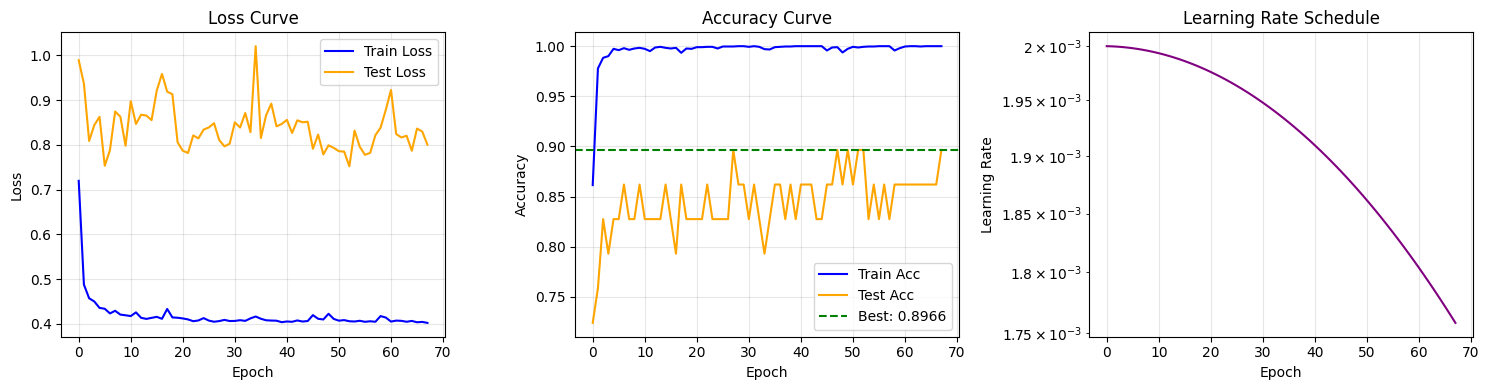

In [24]:
# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(train_losses, label="Train Loss", color="blue")
axes[0].plot(test_losses, label="Test Loss", color="orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accs, label="Train Acc", color="blue")
axes[1].plot(test_accs, label="Test Acc", color="orange")
axes[1].axhline(
    y=best_acc, color="green", linestyle="--", label=f"Best: {best_acc:.4f}"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate curve
axes[2].plot(learning_rates, color="purple")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
plt.show()

## 8. Evaluation

In [25]:
# Load best model
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

<All keys matched successfully>

In [26]:
log_info("Evaluation ...")
crit = nn.CrossEntropyLoss()
_, te_acc, preds, gts = evaluate(model, test_loader, crit, DEVICE)
log_info(f"Accuracy: {te_acc:.4f}")

# F1 Score
f1_macro = f1_score(gts, preds, average="macro")
f1_weighted = f1_score(gts, preds, average="weighted")
print(f"\nF1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Classification Report
label_ids = list(range(NUM_CLASSES))
if len(gts) > 0:
    print("\nClassification Report:")
    print(
        classification_report(
            gts,
            preds,
            labels=label_ids,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(gts, preds, labels=label_ids)
    print("\nConfusion Matrix:")
    hdr = "          " + "  ".join(f"{n[:6]:>6s}" for n in CLASS_NAMES)
    print(hdr)
    for i, row in enumerate(cm):
        print(f"  {CLASS_NAMES[i][:8]:>8s}  " + "  ".join(f"{v:>6d}" for v in row))

[22:27:49] INFO - Evaluation ...
[22:27:50] INFO - Accuracy: 0.8966

F1 Score (Macro): 0.8818
F1 Score (Weighted): 0.8924

Classification Report:
              precision    recall  f1-score   support

        grab     0.8333    0.8333    0.8333         6
     release     1.0000    1.0000    1.0000         6
    swipe_up     0.7500    0.6000    0.6667         5
  swipe_down     0.8333    1.0000    0.9091         5
       noise     1.0000    1.0000    1.0000         7

    accuracy                         0.8966        29
   macro avg     0.8833    0.8867    0.8818        29
weighted avg     0.8937    0.8966    0.8924        29


Confusion Matrix:
            grab  releas  swipe_  swipe_   noise
      grab       5       0       1       0       0
   release       0       6       0       0       0
  swipe_up       1       0       3       1       0
  swipe_do       0       0       0       5       0
     noise       0       0       0       0       7


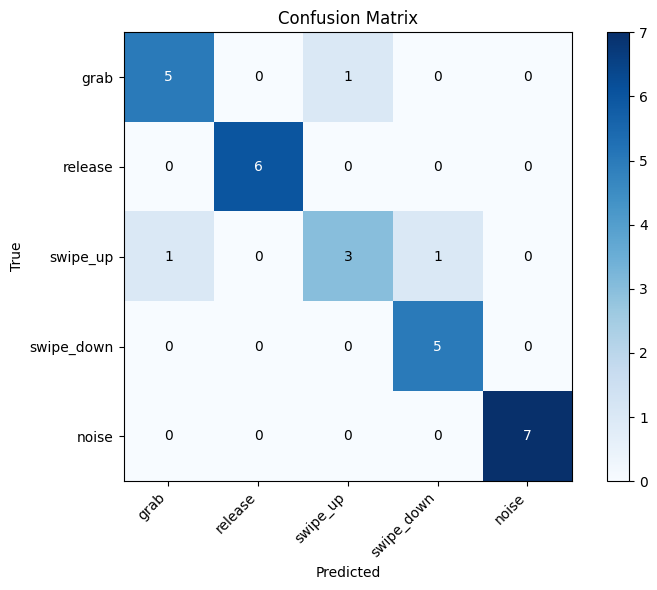

In [27]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

# Add values
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        text = ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
plt.show()

## 9. Save Model Weights

In [28]:
# Save best model
best_path = os.path.join(save_dir, "gesture_tcn_best.pth")
torch.save(model.state_dict(), best_path)
log_info(f"Saved model to {best_path}")

# Save training history
history = {
    "train_losses": train_losses,
    "test_losses": test_losses,
    "train_accs": train_accs,
    "test_accs": test_accs,
    "learning_rates": learning_rates,
    "best_epoch": best_epoch,
    "best_acc": best_acc,
    "f1_macro": f1_macro,
    "f1_weighted": f1_weighted,
}
history_path = os.path.join(save_dir, "training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
log_info(f"Saved training history to {history_path}")

[22:27:52] INFO - Saved model to checkpoints/gesture_tcn_best.pth
[22:27:52] INFO - Saved training history to checkpoints/training_history.json


In [31]:
# copy to Google Drive
"""
import shutil

drive_path = "/content/drive/MyDrive/checkpoints"
shutil.copytree("checkpoints", drive_path, dirs_exist_ok=True)
print(f"File copy to google drive: {drive_path}")
"""

'\nimport shutil\n\ndrive_path = "/content/drive/MyDrive/checkpoints"\nshutil.copytree("checkpoints", drive_path, dirs_exist_ok=True)\nprint(f"File copy to google drive: {drive_path}")\n'

## Summary

This notebook has:
1. Loaded preprocessed data from cache
2. Defined the GestureTCN model
3. Trained the model with early stopping
4. Plotted loss and accuracy curves
5. Evaluated the model with F1 score, classification report, and confusion matrix
6. Saved the best model weights

**Output files:**
- `checkpoints/gesture_tcn_best.pth` - Best model weights
- `checkpoints/training_curves.png` - Training visualization
- `checkpoints/confusion_matrix.png` - Confusion matrix
- `checkpoints/training_history.json` - Training history